# SegFormer-B2 Fine-tuning for Fault Detection

## Why SegFormer over U-Net?
- U-Net: ImageNet pretrained encoder only (classification features)
- SegFormer: ADE20K pretrained encoder + decoder (segmentation features)
- Better starting point for pixel-level fault detection
- Transformer attention captures long-range linear fault patterns

## Strategy
- Start with Carrizo 256×256 (best region, IoU=0.251 with U-Net)
- Differential lr: encoder=1e-5, decoder=1e-4
- Compare directly with U-Net baseline

In [1]:
# ============================================================
# Cell 1: Install
# ============================================================
!pip install -q transformers accelerate

In [1]:
# ============================================================
# Cell 2: Setup
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import gc, json, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import SegformerForSemanticSegmentation
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

BASE_DIR   = Path('/content/drive/MyDrive/prithvi_fault')
PATCH_BASE = BASE_DIR / 'data' / 'patches'
CKPT_BASE  = BASE_DIR / 'checkpoints'
CKPT_BASE.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Mounted at /content/drive
Device: Tesla T4
VRAM: 15.6 GB
Setup complete.


In [2]:
# ============================================================
# Cell 3: Dataset
# Same as U-Net pipeline — no changes needed
# ============================================================

class DEMDataset(Dataset):
    """
    Input:  (3, H, W) float32 — [hillshade, slope, hillshade]
    Output: (H, W)    int64   — 0=background, 1=fault
    """
    def __init__(self, npz_path, augment=False):
        data  = np.load(npz_path)
        imgs  = np.clip(np.nan_to_num(
            data['images'].astype(np.float32), nan=0.0), 0, 1)
        masks = data['masks'].astype(np.int64)

        self.images    = torch.from_numpy(imgs).float()
        self.masks     = torch.from_numpy(masks)
        self.augment   = augment
        self.has_fault = (masks.sum(axis=(1,2)) > 0)

        n, nf = len(self.images), int(self.has_fault.sum())
        print(f'  {Path(npz_path).name}: {n} patches | fault={nf} ({nf/n*100:.0f}%)')

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img  = self.images[idx].clone()
        mask = self.masks[idx].clone()
        if self.augment:
            if torch.rand(1) > 0.5:
                img  = torch.flip(img,  [-1])
                mask = torch.flip(mask, [-1])
            if torch.rand(1) > 0.5:
                img  = torch.flip(img,  [-2])
                mask = torch.flip(mask, [-2])
            if torch.rand(1) > 0.5:
                k    = torch.randint(1, 4, (1,)).item()
                img  = torch.rot90(img,  k, [-2,-1])
                mask = torch.rot90(mask, k, [-2,-1])
            if torch.rand(1) > 0.5:
                img = (img * (0.8 + torch.rand(1)*0.4)).clamp(0,1)
        return img, mask

print('DEMDataset defined.')

DEMDataset defined.


In [3]:
# ============================================================
# Cell 4: Loss + Metrics
# Same loss as U-Net — weighted CE + Dice
# ============================================================

class FaultLoss(nn.Module):
    def __init__(self, fault_weight=5.0):
        super().__init__()
        w       = torch.tensor([1.0, fault_weight]).float().to(device)
        self.ce = nn.CrossEntropyLoss(weight=w)

    def forward(self, logits, targets):
        # logits: (B, 2, H, W) — same format as U-Net output
        ce    = self.ce(logits, targets)
        prob  = torch.softmax(logits, dim=1)[:, 1]
        tgt_f = (targets == 1).float()
        inter = (prob * tgt_f).sum(dim=(1,2))
        union = prob.sum(dim=(1,2)) + tgt_f.sum(dim=(1,2))
        dice  = 1.0 - (2*inter + 1) / (union + 1)
        return ce + dice.mean()


def compute_metrics(logits, targets, threshold=0.5):
    prob  = torch.softmax(logits, dim=1)[:, 1]
    preds = (prob > threshold).long()
    tp = ((preds==1)&(targets==1)).sum().float()
    fp = ((preds==1)&(targets==0)).sum().float()
    fn = ((preds==0)&(targets==1)).sum().float()
    tn = ((preds==0)&(targets==0)).sum().float()
    return {
        'mIoU':     ((tp/(tp+fp+fn+1e-8)+tn/(tn+fp+fn+1e-8))/2).item(),
        'IoU_fault': (tp/(tp+fp+fn+1e-8)).item(),
        'F1':        (2*tp/(2*tp+fp+fn+1e-8)).item(),
    }


def tune_threshold(model, val_ds, batch_size=16):
    loader = DataLoader(val_ds, batch_size=batch_size,
                        shuffle=False, num_workers=0)
    model.eval()
    all_probs, all_masks = [], []
    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.float().to(device)
            logits = forward_segformer(model, imgs)
            all_probs.append(logits.softmax(1)[:,1].cpu().numpy())
            all_masks.append(masks.numpy())
    probs = np.concatenate(all_probs).ravel()
    masks = np.concatenate(all_masks).ravel()

    print('\nThreshold  IoU_fault   F1')
    print('-'*35)
    best_t, best_iou = 0.5, 0.0
    for t in np.arange(0.05, 0.55, 0.05):
        pred = (probs > t).astype(int)
        tp   = ((pred==1)&(masks==1)).sum()
        fp   = ((pred==1)&(masks==0)).sum()
        fn   = ((pred==0)&(masks==1)).sum()
        iou  = tp/(tp+fp+fn+1e-8)
        f1   = 2*tp/(2*tp+fp+fn+1e-8)
        print(f'  {t:.2f}      {iou:.4f}     {f1:.4f}')
        if iou > best_iou:
            best_iou, best_t = iou, t
    print(f'\nOptimal threshold: {best_t:.2f} (IoU_fault={best_iou:.4f})')
    return best_t, best_iou


def evaluate_test(model, test_ds, threshold, batch_size=16):
    loader = DataLoader(test_ds, batch_size=batch_size,
                        shuffle=False, num_workers=0)
    model.eval()
    all_probs, all_masks = [], []
    with torch.no_grad():
        for imgs, masks in loader:
            imgs   = imgs.float().to(device)
            logits = forward_segformer(model, imgs)
            all_probs.append(logits.softmax(1)[:,1].cpu().numpy())
            all_masks.append(masks.numpy())
    probs = np.concatenate(all_probs).ravel()
    masks = np.concatenate(all_masks).ravel()
    pred  = (probs > threshold).astype(int)
    tp = ((pred==1)&(masks==1)).sum()
    fp = ((pred==1)&(masks==0)).sum()
    fn = ((pred==0)&(masks==1)).sum()
    tn = ((pred==0)&(masks==0)).sum()
    results = {
        'threshold': float(threshold),
        'mIoU':      float((tp/(tp+fp+fn+1e-8)+tn/(tn+fp+fn+1e-8))/2),
        'IoU_fault': float(tp/(tp+fp+fn+1e-8)),
        'F1':        float(2*tp/(2*tp+fp+fn+1e-8)),
        'Accuracy':  float((tp+tn)/(tp+tn+fp+fn+1e-8)),
    }
    print('='*50)
    print(f'TEST RESULTS (threshold={threshold:.2f})')
    print('='*50)
    for k, v in results.items():
        if k != 'threshold':
            print(f'  {k:12s}: {v:.4f}')
    return results

print('Loss / Metrics defined.')

Loss / Metrics defined.


In [4]:
# ============================================================
# Cell 5: SegFormer model + forward helper
#
# SegFormer output: (B, num_labels, H/4, W/4)
#   → needs upsampling back to (B, 2, H, W)
#   → then same as U-Net
#
# Differential Learning Rate:
#   encoder (pretrained): 1e-5 — preserve ADE20K features
#   decoder (new head):   1e-4 — learn fault features faster
# ============================================================

def build_segformer(num_labels=2):
    """
    Load SegFormer-B2 pretrained on ADE20K.
    Replace classification head with 2-class fault head.
    """
    model = SegformerForSemanticSegmentation.from_pretrained(
        'nvidia/mit-b2',
        num_labels=num_labels,
        ignore_mismatched_sizes=True,
        id2label={0: 'background', 1: 'fault'},
        label2id={'background': 0, 'fault': 1},
    )
    return model.to(device)


def forward_segformer(model, imgs):
    """
    SegFormer outputs (B, C, H/4, W/4).
    Upsample to original resolution for loss/metrics.
    """
    H, W = imgs.shape[-2], imgs.shape[-1]
    out  = model(pixel_values=imgs).logits  # (B, 2, H/4, W/4)
    return F.interpolate(out, size=(H, W),
                         mode='bilinear', align_corners=False)


def get_optimizer(model, encoder_lr=1e-5, decoder_lr=1e-4, weight_decay=1e-4):
    """
    Differential learning rate:
      encoder (segformer.encoder): lower lr — preserve pretrained features
      decoder (decode_head):       higher lr — learn fault-specific features
    """
    encoder_params = list(model.segformer.parameters())
    decoder_params = list(model.decode_head.parameters())

    return optim.AdamW([
        {'params': encoder_params, 'lr': encoder_lr},
        {'params': decoder_params, 'lr': decoder_lr},
    ], weight_decay=weight_decay)


print('SegFormer helpers defined.')
print('Testing model load...')
model_test = build_segformer()
n_params   = sum(p.numel() for p in model_test.parameters())
print(f'Parameters: {n_params:,}')
del model_test
torch.cuda.empty_cache()
gc.collect()
print('Model OK.')

SegFormer helpers defined.
Testing model load...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

Parameters: 27,348,162
Model OK.


In [5]:
# ============================================================
# Cell 6: Training function
# ============================================================

def train_segformer(region,
                    patch_size_str='256',
                    num_epochs=100,
                    patience=20,
                    batch_size=8,
                    fault_weight=5.0,
                    oversample_w=30.0,
                    encoder_lr=1e-5,
                    decoder_lr=1e-4):
    """
    Fine-tune SegFormer-B2 on one region.
    Uses differential lr: encoder < decoder.
    """
    patch_dir = PATCH_BASE / f'{region}_dem_{patch_size_str}'
    ckpt_dir  = CKPT_BASE  / f'segformer_{region}_{patch_size_str}'
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    print(f'\n{"="*60}')
    print(f'SegFormer-B2 — {region.upper()} {patch_size_str}×{patch_size_str}')
    print(f'encoder_lr={encoder_lr} | decoder_lr={decoder_lr}')
    print(f'{"="*60}')

    # Load datasets
    train_ds = DEMDataset(patch_dir/'train.npz', augment=True)
    val_ds   = DEMDataset(patch_dir/'val.npz',   augment=False)
    test_ds  = DEMDataset(patch_dir/'test.npz',  augment=False)

    weights = np.where(train_ds.has_fault, oversample_w, 1.0)
    sampler = WeightedRandomSampler(
        torch.from_numpy(weights).float(),
        num_samples=len(weights), replacement=True
    )
    LOADER_KW    = dict(num_workers=2, pin_memory=True)
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              sampler=sampler, **LOADER_KW)
    val_loader   = DataLoader(val_ds, batch_size=batch_size,
                              shuffle=False, **LOADER_KW)

    imgs_b, masks_b = next(iter(train_loader))
    fr = (masks_b.sum(dim=(1,2)) > 0).float().mean()
    print(f'Batch fault ratio: {fr:.2f}')
    del imgs_b, masks_b

    # Build model
    model     = build_segformer()
    criterion = FaultLoss(fault_weight=fault_weight)
    optimizer = get_optimizer(model, encoder_lr, decoder_lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-7)
    scaler = torch.amp.GradScaler('cuda')

    best_iou, patience_cnt = 0.0, 0
    history = {'epoch':[], 'train_loss':[], 'val_iou_fault':[], 'val_f1':[]}
    t0 = time.time()

    print(f'\n{"Ep":>4} | {"Loss":>8} | {"mIoU":>7} | '
          f'{"IoU_fault":>10} | {"F1":>7} | {"min":>5}')
    print('-'*55)

    for epoch in range(1, num_epochs+1):

        # Train
        model.train()
        t_loss = 0.0
        for imgs, masks in train_loader:
            imgs  = imgs.float().to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'):
                logits = forward_segformer(model, imgs)
                loss   = criterion(logits, masks)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            t_loss += loss.item()
        t_loss /= len(train_loader)
        scheduler.step()

        # Validate
        model.eval()
        vm = {'mIoU':0.0, 'IoU_fault':0.0, 'F1':0.0}
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs  = imgs.float().to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)
                with torch.amp.autocast('cuda'):
                    logits = forward_segformer(model, imgs)
                m = compute_metrics(logits, masks)
                for k in vm: vm[k] += m[k]
        for k in vm: vm[k] /= len(val_loader)

        history['epoch'].append(epoch)
        history['train_loss'].append(t_loss)
        history['val_iou_fault'].append(vm['IoU_fault'])
        history['val_f1'].append(vm['F1'])

        if epoch % 5 == 0 or epoch <= 3:
            elapsed = (time.time()-t0)/60
            print(f'{epoch:>4} | {t_loss:>8.4f} | {vm["mIoU"]:>7.4f} | '
                  f'{vm["IoU_fault"]:>10.4f} | {vm["F1"]:>7.4f} | '
                  f'{elapsed:>4.1f}m')

        if vm['IoU_fault'] > best_iou:
            best_iou     = vm['IoU_fault']
            patience_cnt = 0
            torch.save({'epoch': epoch,
                        'model_state': model.state_dict(),
                        'val_metrics': vm},
                       ckpt_dir/'best_segformer.pth')
            print(f'  >>> Best (ep={epoch}, IoU_fault={best_iou:.4f})')
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'Early stopping at epoch {epoch}')
                break

    print(f'\nDone: {(time.time()-t0)/60:.1f}min | Best val IoU_fault: {best_iou:.4f}')

    # Threshold tuning
    print('\n--- Threshold Tuning ---')
    ckpt = torch.load(ckpt_dir/'best_segformer.pth', map_location=device)
    model.load_state_dict(ckpt['model_state'])
    best_t, _ = tune_threshold(model, val_ds)

    # Test evaluation
    print('\n--- Test Evaluation ---')
    results = evaluate_test(model, test_ds, best_t)
    results.update({
        'region': region, 'patch_size': patch_size_str,
        'model': 'SegFormer-B2',
        'encoder_lr': encoder_lr, 'decoder_lr': decoder_lr,
        'best_epoch': int(ckpt['epoch'])
    })

    with open(ckpt_dir/'test_results.json', 'w') as f:
        json.dump(results, f, indent=2)

    # Training curve
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], 'b-')
    axes[0].set_title(f'SegFormer {region.upper()} {patch_size_str}×{patch_size_str} — Train Loss')
    axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)
    axes[1].plot(history['val_iou_fault'], 'r--', label='IoU_fault')
    axes[1].plot(history['val_f1'],        'b:',  label='F1')
    axes[1].axhline(best_iou, color='r', ls=':', alpha=0.5,
                    label=f'Best:{best_iou:.4f}')
    axes[1].set_title(f'SegFormer {region.upper()} — Val Metrics')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(ckpt_dir/f'segformer_{region}_{patch_size_str}_curve.png', dpi=150)
    plt.show()
    plt.close()

    # Free GPU memory
    del model, optimizer, scheduler, scaler, criterion
    del train_ds, val_ds, test_ds, train_loader, val_loader
    torch.cuda.empty_cache()
    gc.collect()
    print('GPU memory freed.')

    return results

print('train_segformer() defined.')

train_segformer() defined.


In [ ]:
# ============================================================
# Cell 7: Run — Carrizo 256×256
#
# U-Net baseline: IoU_fault = 0.251
# Target: beat 0.251 with SegFormer
# ============================================================

results = train_segformer(
    region       = 'carrizo',
    patch_size_str = '256',
    num_epochs   = 100,
    patience     = 20,
    batch_size   = 8,
    fault_weight = 5.0,
    oversample_w = 30.0,
    encoder_lr   = 1e-5,   # low — preserve ADE20K features
    decoder_lr   = 1e-4    # high — learn fault features
)

print(f'\nSegFormer Carrizo 256: IoU_fault = {results["IoU_fault"]:.4f}')
print(f'U-Net    Carrizo 256: IoU_fault = 0.2514')
print(f'Improvement: {(results["IoU_fault"]-0.2514)/0.2514*100:+.1f}%')


SegFormer-B2 — CARRIZO 256×256
encoder_lr=1e-05 | decoder_lr=0.0001
  train.npz: 10572 patches | fault=392 (4%)
  val.npz: 2265 patches | fault=84 (4%)
  test.npz: 2267 patches | fault=84 (4%)
Batch fault ratio: 0.62


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta


  Ep |     Loss |    mIoU |  IoU_fault |      F1 |   min
-------------------------------------------------------
   1 |   1.2169 |  0.5007 |     0.0106 |  0.0162 |  2.5m
  >>> Best (ep=1, IoU_fault=0.0106)
   2 |   1.0973 |  0.4975 |     0.0106 |  0.0162 |  4.8m
   3 |   1.0296 |  0.5012 |     0.0113 |  0.0170 |  7.1m
  >>> Best (ep=3, IoU_fault=0.0113)
   5 |   0.9354 |  0.5027 |     0.0114 |  0.0170 | 11.8m
  >>> Best (ep=5, IoU_fault=0.0114)
  >>> Best (ep=7, IoU_fault=0.0114)
  >>> Best (ep=9, IoU_fault=0.0121)
  10 |   0.8525 |  0.5032 |     0.0114 |  0.0170 | 23.4m
  15 |   0.8041 |  0.5032 |     0.0113 |  0.0169 | 35.0m
  20 |   0.7448 |  0.5035 |     0.0114 |  0.0169 | 46.6m
  >>> Best (ep=22, IoU_fault=0.0122)
  25 |   0.7398 |  0.5036 |     0.0114 |  0.0169 | 58.2m
  30 |   0.7235 |  0.5036 |     0.0116 |  0.0171 | 69.8m
  35 |   0.7293 |  0.5038 |     0.0120 |  0.0176 | 81.5m



Trying encoder_lr=5e-05

SegFormer-B2 — CARRIZO 256×256
encoder_lr=5e-05 | decoder_lr=0.0001


model.safetensors:   0%|          | 0.00/98.9M [00:00<?, ?B/s]

  train.npz: 10572 patches | fault=392 (4%)
  val.npz: 2265 patches | fault=84 (4%)
  test.npz: 2267 patches | fault=84 (4%)
Batch fault ratio: 0.75


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta


  Ep |     Loss |    mIoU |  IoU_fault |      F1 |   min
-------------------------------------------------------
   1 |   1.1962 |  0.4985 |     0.0108 |  0.0166 |  3.4m
  >>> Best (ep=1, IoU_fault=0.0108)
   2 |   1.0545 |  0.5021 |     0.0123 |  0.0182 |  6.9m
  >>> Best (ep=2, IoU_fault=0.0123)
   3 |   0.9718 |  0.5024 |     0.0121 |  0.0179 | 10.2m
   5 |   0.8614 |  0.5029 |     0.0112 |  0.0169 | 16.9m
  >>> Best (ep=7, IoU_fault=0.0124)
  10 |   0.7599 |  0.5033 |     0.0118 |  0.0175 | 33.3m
  15 |   0.7095 |  0.5034 |     0.0110 |  0.0165 | 49.7m
  20 |   0.7322 |  0.5033 |     0.0109 |  0.0164 | 66.2m
Early stopping at epoch 22

Done: 72.8min | Best val IoU_fault: 0.0124

--- Threshold Tuning ---

Threshold  IoU_fault   F1
-----------------------------------
  0.05      0.0034     0.0069
  0.10      0.1906     0.3201
  0.15      0.2537     0.4047
  0.20      0.2556     0.4071
  0.25      0.2629     0.4164
  0.30      0.2666     0.4210
  0.35      0.2691     0.4240
  0.40   

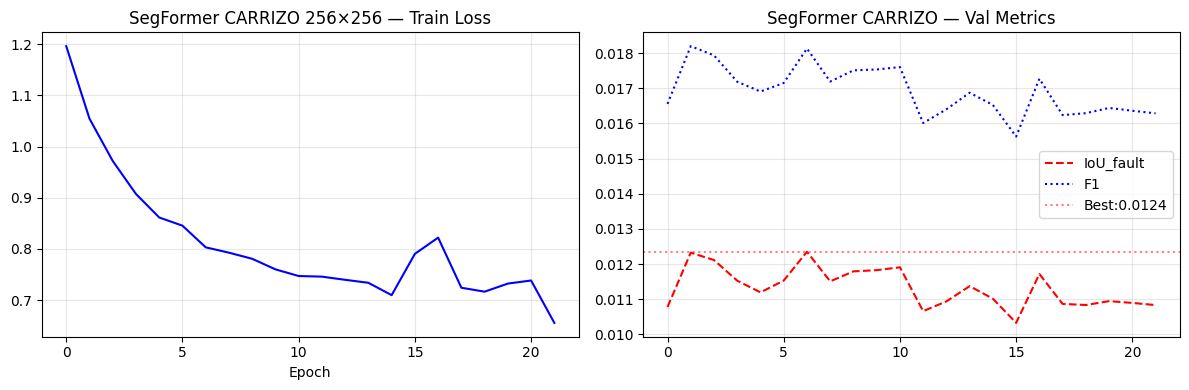

GPU memory freed.

Trying encoder_lr=0.0001

SegFormer-B2 — CARRIZO 256×256
encoder_lr=0.0001 | decoder_lr=0.0001
  train.npz: 10572 patches | fault=392 (4%)
  val.npz: 2265 patches | fault=84 (4%)
  test.npz: 2267 patches | fault=84 (4%)
Batch fault ratio: 0.12


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta


  Ep |     Loss |    mIoU |  IoU_fault |      F1 |   min
-------------------------------------------------------
   1 |   1.2245 |  0.4950 |     0.0112 |  0.0169 |  3.3m
  >>> Best (ep=1, IoU_fault=0.0112)
   2 |   1.0699 |  0.4991 |     0.0117 |  0.0176 |  6.7m
  >>> Best (ep=2, IoU_fault=0.0117)
   3 |   0.9899 |  0.5018 |     0.0123 |  0.0181 | 10.0m
  >>> Best (ep=3, IoU_fault=0.0123)
   5 |   0.8802 |  0.5030 |     0.0128 |  0.0187 | 16.6m
  >>> Best (ep=5, IoU_fault=0.0128)
  >>> Best (ep=9, IoU_fault=0.0134)
  10 |   0.7598 |  0.5032 |     0.0118 |  0.0175 | 33.0m


In [ ]:
# Cell 8: encoder_lr tuning — skip 1e-5 (already done, IoU=0.3687)

encoder_lrs = [5e-5, 1e-4]
tuning_results = {}

# Already completed result
tuning_results['enc_lr=1e-05'] = 0.3687

for enc_lr in encoder_lrs:
    print(f'\nTrying encoder_lr={enc_lr}')
    r = train_segformer(
        region         = 'carrizo',
        patch_size_str = '256',
        num_epochs     = 50,
        patience       = 15,
        batch_size     = 8,
        fault_weight   = 5.0,
        oversample_w   = 30.0,
        encoder_lr     = enc_lr,
        decoder_lr     = 1e-4
    )
    tuning_results[f'enc_lr={enc_lr}'] = r['IoU_fault']
    torch.cuda.empty_cache()
    gc.collect()

print('\n--- Encoder LR Tuning Results ---')
for k, v in tuning_results.items():
    marker = ' ← best' if v == max(tuning_results.values()) else ''
    print(f'  {k}: IoU_fault={v:.4f}{marker}')

best_enc_lr = max(tuning_results, key=tuning_results.get)
print(f'\nBest encoder_lr: {best_enc_lr}')
print(f'U-Net 256×256 baseline: IoU_fault=0.2514')

In [ ]:
# ============================================================
# Cell 9: Hyperparameter tuning — fault_weight sweep
#
# Run AFTER finding best encoder_lr
# ============================================================

fault_weights = [3.0, 5.0, 10.0, 20.0]
fw_results = {}

BEST_ENC_LR = 1e-5  # update after Cell 8

for fw in fault_weights:
    print(f'\nTrying fault_weight={fw}')
    r = train_segformer(
        region         = 'carrizo',
        patch_size_str = '256',
        num_epochs     = 50,
        patience       = 15,
        batch_size     = 8,
        fault_weight   = fw,
        oversample_w   = 30.0,
        encoder_lr     = BEST_ENC_LR,
        decoder_lr     = 1e-4
    )
    fw_results[f'fw={fw}'] = r['IoU_fault']
    torch.cuda.empty_cache()
    gc.collect()

print('\n--- Fault Weight Tuning Results ---')
for k, v in fw_results.items():
    print(f'  {k}: IoU_fault={v:.4f}')

In [ ]:
# ============================================================
# Cell 10: Final comparison — SegFormer vs U-Net
# ============================================================

print('='*60)
print('FINAL COMPARISON: SegFormer-B2 vs U-Net ResNet34')
print('='*60)
print(f'{"Model":<30} {"IoU_fault":>12} {"F1":>8} {"mIoU":>8}')
print('-'*60)

# U-Net baselines
unet_results = [
    ('U-Net ResNet34 128×128',  0.1299, 0.2299, 0.5555),
    ('U-Net ResNet34 256×256',  0.2514, 0.4019, 0.6219),
    ('U-Net ResNet34 512×512',  0.2661, 0.4203, 0.6300),
]
for name, iou, f1, miou in unet_results:
    print(f'{name:<30} {iou:>12.4f} {f1:>8.4f} {miou:>8.4f}')

# Load SegFormer result
sf_path = CKPT_BASE / 'segformer_carrizo_256' / 'test_results.json'
if sf_path.exists():
    with open(sf_path) as f:
        sf = json.load(f)
    print(f'{"SegFormer-B2 256×256":<30} '
          f'{sf["IoU_fault"]:>12.4f} '
          f'{sf["F1"]:>8.4f} '
          f'{sf["mIoU"]:>8.4f} ← NEW')
    improvement = (sf['IoU_fault'] - 0.2514) / 0.2514 * 100
    print(f'\nImprovement over U-Net 256×256: {improvement:+.1f}%')

print('='*60)